### Классификация активностей человека

Рассмотрим задачу классификации набора данных, содержащего временные ряды, с помощью CWT + CNN.

Набор данных UCI-HAR (Human Activity Recognition) содержит измерения датчиков людей, выполняющих различные виды физической активности, например, подъем или спуск по лестнице, лежание, стояние, ходьбу и т. д. Данные в наборе получены от тридцати добровольцев с закрепленным на поясе Samsung Galaxy S II. В датасете более 10 000 сигналов, каждый из которых состоит из девяти компонентов (ускорение x, ускорение y, ускорение z, данные гироскопа x,y,z и т. д.). 

Датасет доступен по ссылке:

https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

Сначала сформируем датасет для обучения. Для этого подгрузим сигналы и сделаем их НВП.

In [2]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm import tqdm

In [3]:
activities_description = {
    1: 'walking',
    2: 'walking upstairs',
    3: 'walking downstairs',
    4: 'sitting',
    5: 'standing',
    6: 'laying'
}

def read_signals(filename):
    with open(filename, 'r') as fp:
        data = fp.read().splitlines()
        data = map(lambda x: x.rstrip().lstrip().split(), data)
        data = [list(map(float, line)) for line in data]
    return data

def read_labels(filename):        
    with open(filename, 'r') as fp:
        activities = fp.read().splitlines()
        activities = list(map(lambda x: int(x)-1, activities))
    return activities

def randomize(dataset, labels):
    permutation = np.random.permutation(labels.shape[0])
    shuffled_dataset = dataset[permutation, :, :]
    shuffled_labels = labels[permutation]
    return shuffled_dataset, shuffled_labels

INPUT_FOLDER_TRAIN = './HAR_Dataset/train/InertialSignals/'
INPUT_FOLDER_TEST = './HAR_Dataset/test/InertialSignals/'

INPUT_FILES_TRAIN = ['body_acc_x_train.txt', 'body_acc_y_train.txt', 'body_acc_z_train.txt', 
                     'body_gyro_x_train.txt', 'body_gyro_y_train.txt', 'body_gyro_z_train.txt',
                     'total_acc_x_train.txt', 'total_acc_y_train.txt', 'total_acc_z_train.txt']

INPUT_FILES_TEST = ['body_acc_x_test.txt', 'body_acc_y_test.txt', 'body_acc_z_test.txt', 
                     'body_gyro_x_test.txt', 'body_gyro_y_test.txt', 'body_gyro_z_test.txt',
                     'total_acc_x_test.txt', 'total_acc_y_test.txt', 'total_acc_z_test.txt']

LABELFILE_TRAIN = './HAR_Dataset/train/y_train.txt'
LABELFILE_TEST = './HAR_Dataset/test/y_test.txt'

train_signals, test_signals = [], []

In [4]:
for input_file in INPUT_FILES_TRAIN:
    signal = read_signals(INPUT_FOLDER_TRAIN + input_file)
    train_signals.append(signal)
train_signals = np.transpose(np.array(train_signals), (1, 2, 0))

for input_file in INPUT_FILES_TEST:
    signal = read_signals(INPUT_FOLDER_TEST + input_file)
    test_signals.append(signal)
test_signals = np.transpose(np.array(test_signals), (1, 2, 0))

train_labels = read_labels(LABELFILE_TRAIN)
test_labels = read_labels(LABELFILE_TEST)

[no_signals_train, no_steps_train, no_components_train] = np.shape(train_signals)
[no_signals_test, no_steps_test, no_components_test] = np.shape(test_signals)
no_labels = len(np.unique(train_labels[:]))

print("Обучающая выборка состоит из {} сигналов, каждый сигнал длины {} и из {} компонент ".format(no_signals_train, no_steps_train, no_components_train))
print("Тестовая выборка состоит из {} сигналов, каждый сигнал длины {} и из {} компонент ".format(no_signals_test, no_steps_test, no_components_test))
print("Обучающая выборка состоит из {} меток классов с распределением:\n {}".format(np.shape(train_labels)[0], Counter(train_labels[:])))
print("Тестовая выборка состоит из {} меток классовс распределением:\n {}".format(np.shape(test_labels)[0], Counter(test_labels[:])))

uci_har_signals_train, uci_har_labels_train = randomize(train_signals, np.array(train_labels))
uci_har_signals_test, uci_har_labels_test = randomize(test_signals, np.array(test_labels))

Обучающая выборка состоит из 7352 сигналов, каждый сигнал длины 128 и из 9 компонент 
Тестовая выборка состоит из 2947 сигналов, каждый сигнал длины 128 и из 9 компонент 
Обучающая выборка состоит из 7352 меток классов с распределением:
 Counter({5: 1407, 4: 1374, 3: 1286, 0: 1226, 1: 1073, 2: 986})
Тестовая выборка состоит из 2947 меток классовс распределением:
 Counter({5: 537, 4: 532, 0: 496, 3: 491, 1: 471, 2: 420})


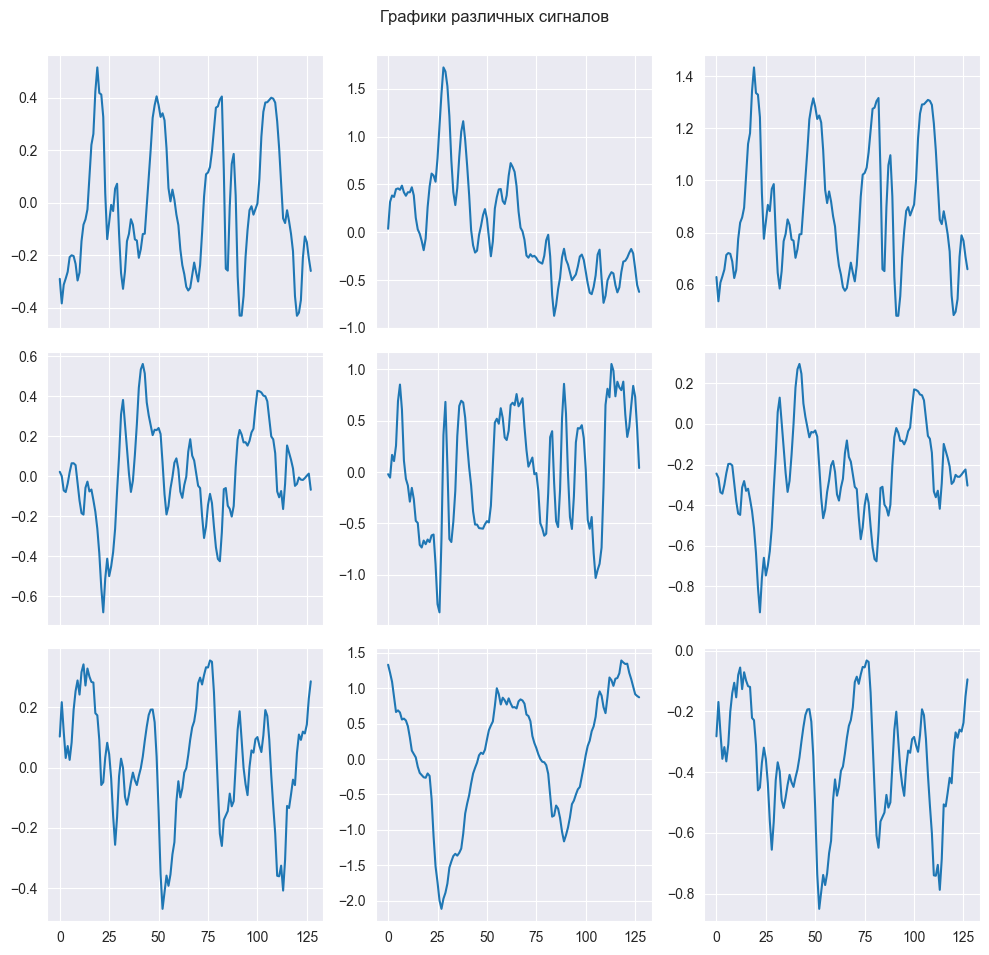

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10), sharex=True)
x = np.arange(0, 128, 1.0)
for i in range(3):
    for j in range(3):
        axs[i, j].plot(x, uci_har_signals_train[0,:,i+3*j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Графики различных сигналов")
plt.show()

In [6]:
scales = range(1,128,2)
waveletname = 'morl'
len(scales)

64

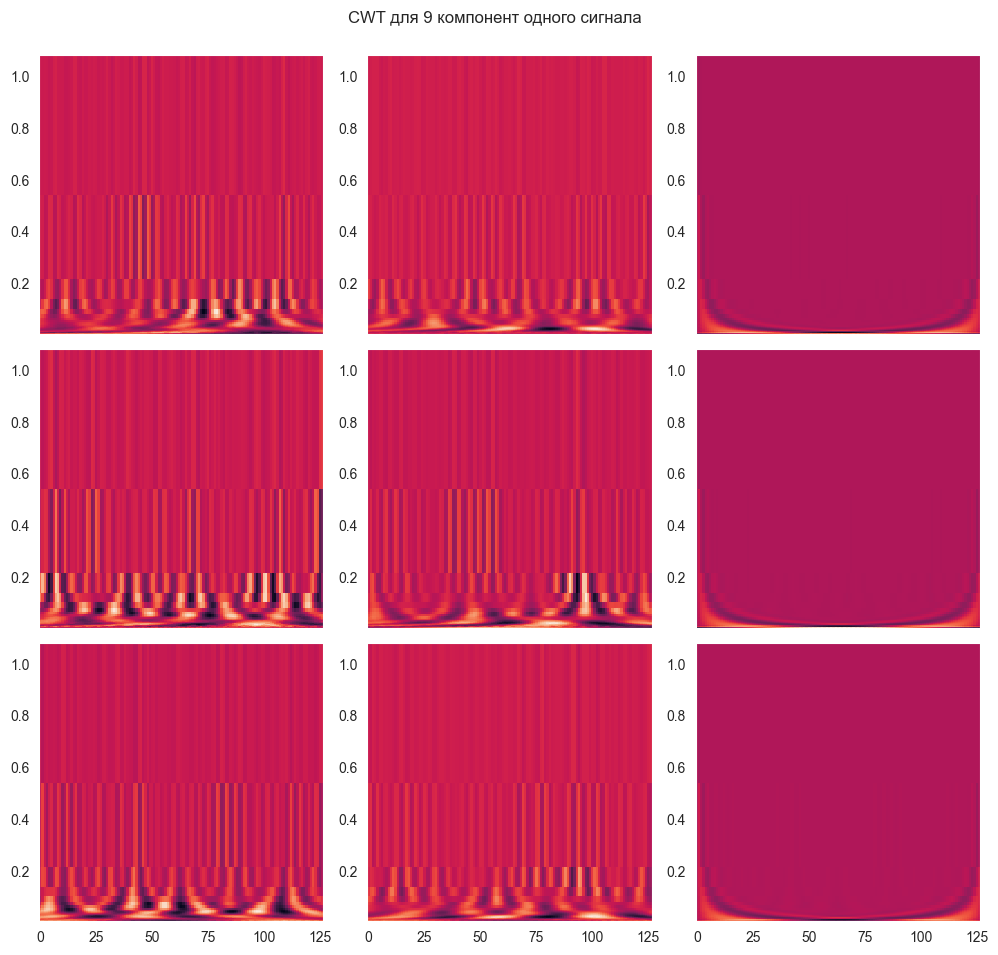

In [7]:
ii = 1000
data_cwt = np.ndarray(shape=(9, len(scales), 127))
freq_cwt = np.ndarray(shape=(9, len(scales)))

for jj in range(0,9):
    signal = uci_har_signals_train[ii, :, jj]
    coeff, freq = pywt.cwt(signal, scales, waveletname, 1)
    coeff_ = coeff[:,:127]
    data_cwt[jj, :, :, ] = coeff_.astype('float32')
    freq_cwt[jj, :] = freq

fig, axs = plt.subplots(3, 3, figsize=(10, 10), sharex=True)

for i in range(3):
    for j in range(3):
        axs[i,j].pcolormesh(np.arange(127), freq_cwt[i+3*j], data_cwt[i+3*j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("CWT для 9 компонент одного сигнала")
plt.show()

### Задача. 

Сформировать свёрточную ИНС и обучить на датасете `(train_data_cwt, target_train)`.

Точность на тестовом датасете не меньше 95%.

In [8]:
scales = range(1,128,2)
waveletname = 'morl'
train_size = 7352 
test_size = 2947

# Сформировать датасеты
train_data_cwt = np.ndarray(shape=(train_size, 9, len(scales), 127))
test_data_cwt = np.ndarray(shape=(test_size, 9, len(scales), 127))


Нахождение CWT занимает время (порядка 5 мин). Сформированные массивы с CWT можно сохранить.

In [9]:
with open('data_train.npy', 'wb') as f:
    np.save(f, train_data_cwt)
with open('data_test.npy', 'wb') as f:
    np.save(f, test_data_cwt)

In [10]:
with open('data_train.npy', 'rb') as f:
    train_data_cwt = np.load(f)
with open('data_test.npy', 'rb') as f:
    test_data_cwt = np.load(f)

Сформируем обучающий и тестовый датасеты.

In [11]:
x_train = train_data_cwt
y_train = list(uci_har_labels_train[:train_size])
x_test = test_data_cwt
y_test = list(uci_har_labels_test[:test_size])
num_classes = 6

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (7352, 9, 64, 127)
7352 train samples
2947 test samples


В векторах `y_train` и `y_test` содержатся индексы тех или иных активностей. Переведём их в бинарные вектора методом one-hot encoding.

In [12]:
import torch
import torch.nn as nn

def encode_labels(labels, num_of_classes): 
    num = len(labels)
    target = torch.zeros(num, num_of_classes).float()
    for i, l in enumerate(labels):
        target[i, l] = 1
    return target

target_train = encode_labels(y_train, num_classes)
target_test = encode_labels(y_test, num_classes)

Сформировать свёрточную ИНС и обучить на датасете `(train_data_cwt, target_train)`.

Точность на тестовом датасете `(test_data_cwt, target_test)` не меньше 95%.

First let's prepare data and check

In [13]:
def check_data(x_train_tensor, y_train_tensor):
    # Diagnostic checks
    print("\n=== INPUT DATA CHECK ===")
    print("x_train_tensor shape:", x_train_tensor.shape)    
    print("x_train_tensor dtype:", x_train_tensor.dtype)
    print("x_train_tensor min:", x_train_tensor.min().item())
    print("x_train_tensor max:", x_train_tensor.max().item())
    print("x_train_tensor mean:", x_train_tensor.mean().item())
    print("x_train_tensor std:", x_train_tensor.std().item())

    print("\n=== LABEL CHECK ===")
    print("y_train_tensor shape:", y_train_tensor.shape)
    print("y_train_tensor unique labels:", torch.unique(y_train_tensor, return_counts=True))
    print("y_train_tensor Sample labels:", y_train_tensor[:10])

    # Show a single training sample (all channels of 1 example)
    sample_index = 0
    print("\n=== Sample Signal Channels ===")
    for channel in range(9):
        print(f"Channel {channel}: min={x_train_tensor[sample_index, channel].min().item():.4f}, "
              f"max={x_train_tensor[sample_index, channel].max().item():.4f}, "
              f"mean={x_train_tensor[sample_index, channel].mean().item():.4f}")
        
# ✅ Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ✅ Prepare data (permute if needed)
# Convert numpy arrays to PyTorch tensors
x_train_tensor = torch.from_numpy(train_data_cwt).float()
y_train_tensor = target_train
check_data(x_train_tensor, y_train_tensor)

Using device: cpu

=== INPUT DATA CHECK ===
x_train_tensor shape: torch.Size([7352, 9, 64, 127])
x_train_tensor dtype: torch.float32
x_train_tensor min: 0.0
x_train_tensor max: 0.0
x_train_tensor mean: 0.0
x_train_tensor std: 0.0

=== LABEL CHECK ===
y_train_tensor shape: torch.Size([7352, 6])
y_train_tensor unique labels: (tensor([0., 1.]), tensor([36760,  7352]))
y_train_tensor Sample labels: tensor([[0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 1.]])

=== Sample Signal Channels ===
Channel 0: min=0.0000, max=0.0000, mean=0.0000
Channel 1: min=0.0000, max=0.0000, mean=0.0000
Channel 2: min=0.0000, max=0.0000, mean=0.0000
Channel 3: min=0.0000, max=0.0000, mean=0.0000
Channel 4: min=0.0000, max=0.0000, mean=0

Let's Re-Generate CWT (train_data_cwt, test_data_cwt)

In [14]:
train_data_cwt = np.zeros((train_size, 9, len(scales), 127), dtype=np.float32)
test_data_cwt = np.zeros((test_size, 9, len(scales), 127), dtype=np.float32)

print("Generating CWT for training data...")
for idx in tqdm(range(train_size)):
    for ch in range(9):
        signal = uci_har_signals_train[idx, :, ch]
        coeff, _ = pywt.cwt(signal, scales, waveletname, 1)
        train_data_cwt[idx, ch] = coeff[:, :127]

print("Generating CWT for test data...")
for idx in tqdm(range(test_size)):
    for ch in range(9):
        signal = uci_har_signals_test[idx, :, ch]
        coeff, _ = pywt.cwt(signal, scales, waveletname, 1)
        test_data_cwt[idx, ch] = coeff[:, :127]

# Save for reuse
np.save("data_train.npy", train_data_cwt)
np.save("data_test.npy", test_data_cwt)

print("✅ Done recomputing and saving CWT data.")
# Convert numpy arrays to PyTorch tensors
x_train_tensor = torch.from_numpy(train_data_cwt).float()
y_train_tensor = target_train
check_data(x_train_tensor, y_train_tensor)


Generating CWT for training data...


100%|██████████| 7352/7352 [10:59<00:00, 11.15it/s]


Generating CWT for test data...


100%|██████████| 2947/2947 [04:21<00:00, 11.29it/s]


✅ Done recomputing and saving CWT data.

=== INPUT DATA CHECK ===
x_train_tensor shape: torch.Size([7352, 9, 64, 127])
x_train_tensor dtype: torch.float32
x_train_tensor min: -10.713598251342773
x_train_tensor max: 11.438118934631348
x_train_tensor mean: 0.037155311554670334
x_train_tensor std: 0.5570935010910034

=== LABEL CHECK ===
y_train_tensor shape: torch.Size([7352, 6])
y_train_tensor unique labels: (tensor([0., 1.]), tensor([36760,  7352]))
y_train_tensor Sample labels: tensor([[0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 1.]])

=== Sample Signal Channels ===
Channel 0: min=-1.7581, max=1.7552, mean=0.0090
Channel 1: min=-1.6627, max=1.7070, mean=0.0031
Channel 2: min=-1.2857, max=1.2903, mean=0.0081


Now data loaded correctly

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report
from tqdm import tqdm

# Define the CNN model
class HARCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(HARCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(9, 32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        )
        
        self.fc = nn.Sequential(
            nn.Linear(128 * 8 * 15, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

# Convert numpy arrays to PyTorch tensors
x_train_tensor = torch.from_numpy(train_data_cwt).float()
x_test_tensor = torch.from_numpy(test_data_cwt).float()

y_train_tensor = target_train
y_test_tensor = target_test

# Create datasets and dataloaders
batch_size = 128
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize model, loss function and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HARCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Training loop
num_epochs = 50
best_accuracy = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        progress_bar.set_postfix(loss=running_loss/(epoch+1))
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            _, labels = torch.max(labels.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    scheduler.step(running_loss)
    
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Test Accuracy: {accuracy:.2f}%')
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        if best_accuracy >= 95:
            print("Reached 95% accuracy, stopping training.")
            break

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Final evaluation
model.eval()
y_pred = []
y_true = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        _, labels = torch.max(labels.data, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# Classification report
target_names = [activities_description[i+1] for i in range(num_classes)]

Epoch 13/50: 100%|██████████| 58/58 [01:06<00:00,  1.15s/it, loss=0.423]


Epoch 13, Loss: 0.0948, Test Accuracy: 91.69%


Epoch 14/50: 100%|██████████| 58/58 [01:02<00:00,  1.07s/it, loss=0.386] 


Epoch 14, Loss: 0.0932, Test Accuracy: 90.80%


Epoch 15/50: 100%|██████████| 58/58 [01:01<00:00,  1.06s/it, loss=0.345] 


...

Epoch 27, Loss: 0.0517, Test Accuracy: 93.65%


Epoch 28/50: 100%|██████████| 58/58 [01:03<00:00,  1.09s/it, loss=0.087] 


Epoch 28, Loss: 0.0420, Test Accuracy: 94.10%


Epoch 29/50: 100%|██████████| 58/58 [01:03<00:00,  1.09s/it, loss=0.116] 


Epoch 29, Loss: 0.0578, Test Accuracy: 95.35%
Reached 95% accuracy, stopping training.


In [19]:
print(classification_report(y_true, y_pred, target_names=target_names))

                    precision    recall  f1-score   support

           walking       1.00      0.94      0.97       496
  walking upstairs       1.00      0.96      0.98       471
walking downstairs       0.90      1.00      0.95       420
           sitting       0.94      0.88      0.91       491
          standing       0.93      0.94      0.94       532
            laying       0.96      1.00      0.98       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [67]:
print(classification_report(y_test, y_pred_labels, target_names=target_names))

                    precision    recall  f1-score   support

           walking       0.95      0.96      0.95       496
  walking upstairs       0.99      0.95      0.97       471
walking downstairs       0.95      0.99      0.97       420
           sitting       0.94      0.87      0.91       491
          standing       0.89      0.95      0.92       532
            laying       0.99      1.00      1.00       537

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



In [35]:
print(classification_report(y_test, y_pred_labels, target_names=target_names))

                    precision    recall  f1-score   support

           walking       0.89      0.96      0.92       496
  walking upstairs       0.95      0.91      0.93       471
walking downstairs       0.99      0.94      0.96       420
           sitting       0.98      0.90      0.94       491
          standing       0.94      0.96      0.95       532
            laying       0.95      1.00      0.97       537

          accuracy                           0.95      2947
         macro avg       0.95      0.94      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



In [16]:
print(classification_report(y_true, y_pred, target_names=target_names))

                    precision    recall  f1-score   support

           walking       1.00      0.94      0.97       496
  walking upstairs       0.99      0.99      0.99       471
walking downstairs       0.94      1.00      0.97       420
           sitting       0.93      0.84      0.88       491
          standing       0.90      0.94      0.92       532
            laying       0.96      1.00      0.98       537

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947

